<a href="https://colab.research.google.com/github/deborahpongeluppe/Deborahpongeluppe/blob/main/Y_Afisha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving costs_us.csv to costs_us.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving orders_log_us.csv to orders_log_us.csv


In [4]:
from google.colab import files
uploaded = files.upload()

Saving visits_log_us.csv to visits_log_us.csv


In [5]:
visits=pd.read_csv('visits_log_us.csv')
orders=pd.read_csv('orders_log_us.csv')
costs=pd.read_csv('costs_us.csv')
print(visits.head())
print(visits.info())

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage

In [6]:
print(orders.head())
print(orders.info())

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None


In [7]:
print(costs.head())
print(costs.info())

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None


In [8]:
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['date'] = visits['Start Ts'].dt.date
daily_users = visits.groupby('date')['Uid'].nunique()
print("Usuários únicos por dia:")
print(daily_users.head())
visits['week'] = visits['Start Ts'].dt.to_period('W')
weekly_users = visits.groupby('week')['Uid'].nunique()
print("Usuários únicos por semana:")
print(weekly_users.head())
visits['month'] = visits['Start Ts'].dt.to_period('M')
monthly_users = visits.groupby('month')['Uid'].nunique()
print("Usuários únicos por mês:")
print(monthly_users.head())

Usuários únicos por dia:
date
2017-06-01    605
2017-06-02    608
2017-06-03    445
2017-06-04    476
2017-06-05    820
Name: Uid, dtype: int64
Usuários únicos por semana:
week
2017-05-29/2017-06-04    2021
2017-06-05/2017-06-11    4129
2017-06-12/2017-06-18    2812
2017-06-19/2017-06-25    2878
2017-06-26/2017-07-02    3064
Freq: W-SUN, Name: Uid, dtype: int64
Usuários únicos por mês:
month
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
Freq: M, Name: Uid, dtype: int64


These figures represent unique users over different time periods—that is, the number of distinct individuals who visited the Y.Afisha website—with analyses conducted on a daily, weekly, and monthly basis.

In [9]:
visits['date'] = visits['Start Ts'].dt.date
sessions_per_day = visits.groupby('date').size()
print("Sessões por dia:")
print(sessions_per_day.head())

Sessões por dia:
date
2017-06-01    664
2017-06-02    658
2017-06-03    477
2017-06-04    510
2017-06-05    893
dtype: int64


This analysis was conducted to determine the number of sessions per day; however, when compared to the previous analysis of unique users, it is evident that the number of daily sessions was low—meaning few users returned to the site.

In [10]:
sessions_per_user = sessions_per_day / daily_users
print("Sessões por usuário:")
print(sessions_per_user.head())

Sessões por usuário:
date
2017-06-01    1.097521
2017-06-02    1.082237
2017-06-03    1.071910
2017-06-04    1.071429
2017-06-05    1.089024
dtype: float64


In [11]:
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
visits['session_duration'] = visits['End Ts'] - visits['Start Ts']
visits['session_duration_sec'] = visits['session_duration'].dt.total_seconds()
print("Estatísticas da duração das sessões (em segundos):")
print(visits['session_duration_sec'].describe())
visits['session_duration_min'] = visits['session_duration_sec'] / 60
print("\nEstatísticas da duração das sessões (em minutos):")
print(visits['session_duration_min'].describe())

Estatísticas da duração das sessões (em segundos):
count    359400.000000
mean        643.025687
std         997.127761
min       -2760.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       42660.000000
Name: session_duration_sec, dtype: float64

Estatísticas da duração das sessões (em minutos):
count    359400.000000
mean         10.717095
std          16.618796
min         -46.000000
25%           2.000000
50%           5.000000
75%          14.000000
max         711.000000
Name: session_duration_min, dtype: float64


In [12]:
negative_sessions = visits[visits['session_duration_sec'] < 0]
print(f"Sessões com duração negativa: {len(negative_sessions)}")
print(f"Porcentagem do total: {len(negative_sessions) / len(visits) * 100:.2f}%")
print("\nExemplos de sessões com duração negativa:")
print(negative_sessions[['Start Ts', 'End Ts', 'session_duration_min']].head())
visits_clean = visits[visits['session_duration_sec'] >= 0].copy()
print(f"Dados originais: {len(visits)} sessões")
print(f"Dados limpos: {len(visits_clean)} sessões")
print(f"Sessões removidas: {len(visits) - len(visits_clean)}")
print("=== ANTES DA LIMPEZA ===")
print(visits['session_duration_min'].describe())
print("\n=== DEPOIS DA LIMPEZA ===")
print(visits_clean['session_duration_min'].describe())

Sessões com duração negativa: 2
Porcentagem do total: 0.00%

Exemplos de sessões com duração negativa:
                  Start Ts              End Ts  session_duration_min
4181   2018-03-25 03:50:00 2018-03-25 03:18:00                 -32.0
177972 2018-03-25 03:55:00 2018-03-25 03:09:00                 -46.0
Dados originais: 359400 sessões
Dados limpos: 359398 sessões
Sessões removidas: 2
=== ANTES DA LIMPEZA ===
count    359400.000000
mean         10.717095
std          16.618796
min         -46.000000
25%           2.000000
50%           5.000000
75%          14.000000
max         711.000000
Name: session_duration_min, dtype: float64

=== DEPOIS DA LIMPEZA ===
count    359398.000000
mean         10.717371
std          16.618420
min           0.000000
25%           2.000000
50%           5.000000
75%          14.000000
max         711.000000
Name: session_duration_min, dtype: float64


Two sessions with negative values ​​were found; consequently, the data was cleaned and these values ​​were removed, as a negative session duration makes no sense. Following this data cleaning, we determined that the average session duration among users is 10 minutes: approximately 25% spend 2 minutes per session, the median is 5 minutes per session, and 75% spend up to 14 minutes per session.

In [13]:
user_visit_days = visits_clean.groupby('Uid')['date'].nunique().reset_index()
user_visit_days.columns = ['Uid', 'days_visited']
print("Distribuição de dias visitados por usuário:")
print(user_visit_days['days_visited'].value_counts().sort_index())
single_day_users = user_visit_days[user_visit_days['days_visited'] == 1]
multi_day_users = user_visit_days[user_visit_days['days_visited'] > 1]
print(f"Usuários que visitaram apenas 1 dia: {len(single_day_users)}")
print(f"Usuários que visitaram múltiplos dias: {len(multi_day_users)}")
print(f"Taxa de retorno: {len(multi_day_users) / len(user_visit_days) * 100:.2f}%")
print("\nEstatísticas dos usuários recorrentes:")
print(f"Usuário mais fiel visitou: {user_visit_days['days_visited'].max()} dias")
print(f"Média de dias visitados: {user_visit_days['days_visited'].mean():.2f}")
print(f"Mediana de dias visitados: {user_visit_days['days_visited'].median()}")

Distribuição de dias visitados por usuário:
days_visited
1      183124
2       27591
3        8484
4        3706
5        1821
        ...  
177         1
179         1
245         1
248         1
259         1
Name: count, Length: 115, dtype: int64
Usuários que visitaram apenas 1 dia: 183124
Usuários que visitaram múltiplos dias: 45045
Taxa de retorno: 19.74%

Estatísticas dos usuários recorrentes:
Usuário mais fiel visitou: 259 dias
Média de dias visitados: 1.45
Mediana de dias visitados: 1.0


An analysis based on user return rates reveals that 80% of users visit the site only once and do not return, while 20% do return; the median duration is one day, meaning half of the users visit on only a single day.

In [14]:
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])
orders['buy_date'] = orders['Buy Ts'].dt.date
first_visit = visits_clean.groupby('Uid')['date'].min().reset_index()
first_visit.columns = ['Uid', 'first_visit_date']
first_purchase = orders.groupby('Uid')['buy_date'].min().reset_index()
first_purchase.columns = ['Uid', 'first_purchase_date']
print(f"Usuários únicos que visitaram: {len(first_visit)}")
print(f"Usuários únicos que compraram: {len(first_purchase)}")
conversion_data = first_visit.merge(first_purchase, on='Uid', how='inner')
conversion_data['days_to_conversion'] = (
    pd.to_datetime(conversion_data['first_purchase_date']) -
    pd.to_datetime(conversion_data['first_visit_date'])
).dt.days
print(f"Usuários que visitaram E compraram: {len(conversion_data)}")
print("\nDistribuição de dias até conversão:")
print(conversion_data['days_to_conversion'].value_counts().sort_index().head(10))

Usuários únicos que visitaram: 228169
Usuários únicos que compraram: 36523
Usuários que visitaram E compraram: 36523

Distribuição de dias até conversão:
days_to_conversion
0    25039
1     1966
2      685
3      452
4      386
5      307
6      264
7      237
8      216
9      162
Name: count, dtype: int64


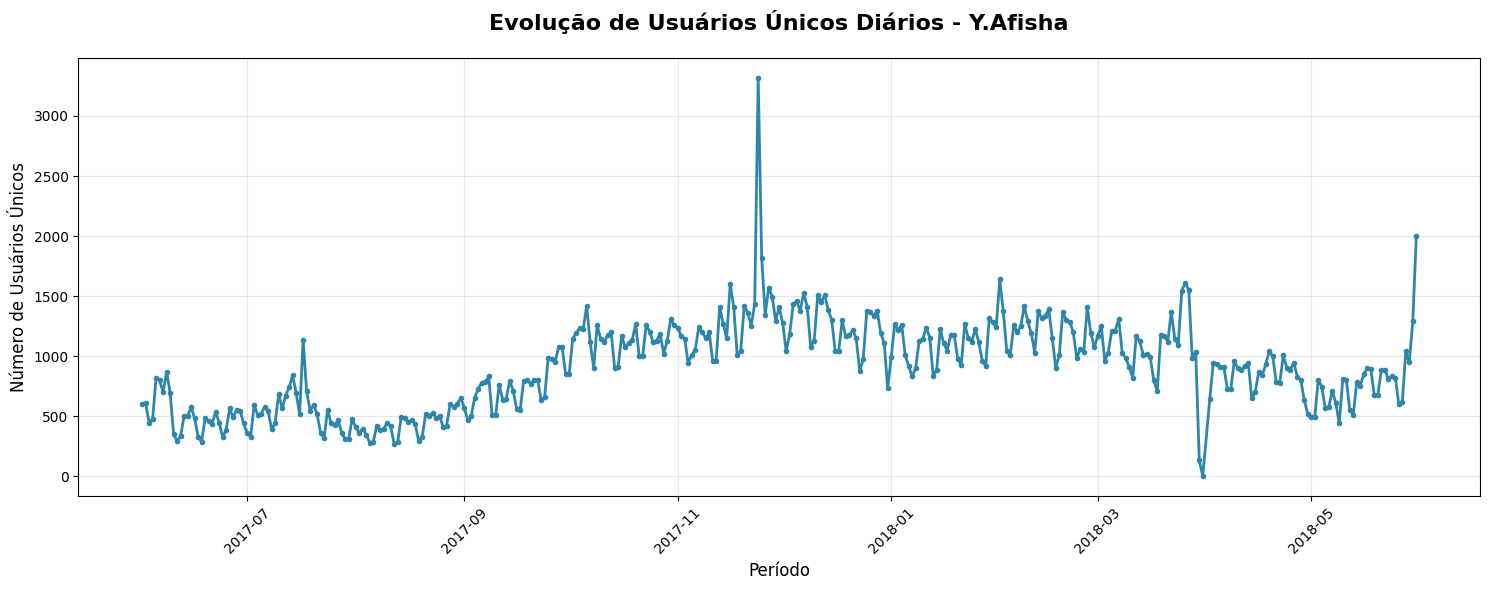

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
daily_users_df = daily_users.reset_index()
daily_users_df['date'] = pd.to_datetime(daily_users_df['date'])
plt.figure(figsize=(15, 6))
plt.plot(daily_users_df['date'], daily_users_df['Uid'],
         linewidth=2, color='#2E86AB', marker='o', markersize=3)
plt.title('Evolução de Usuários Únicos Diários - Y.Afisha',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Período', fontsize=12)
plt.ylabel('Número de Usuários Únicos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

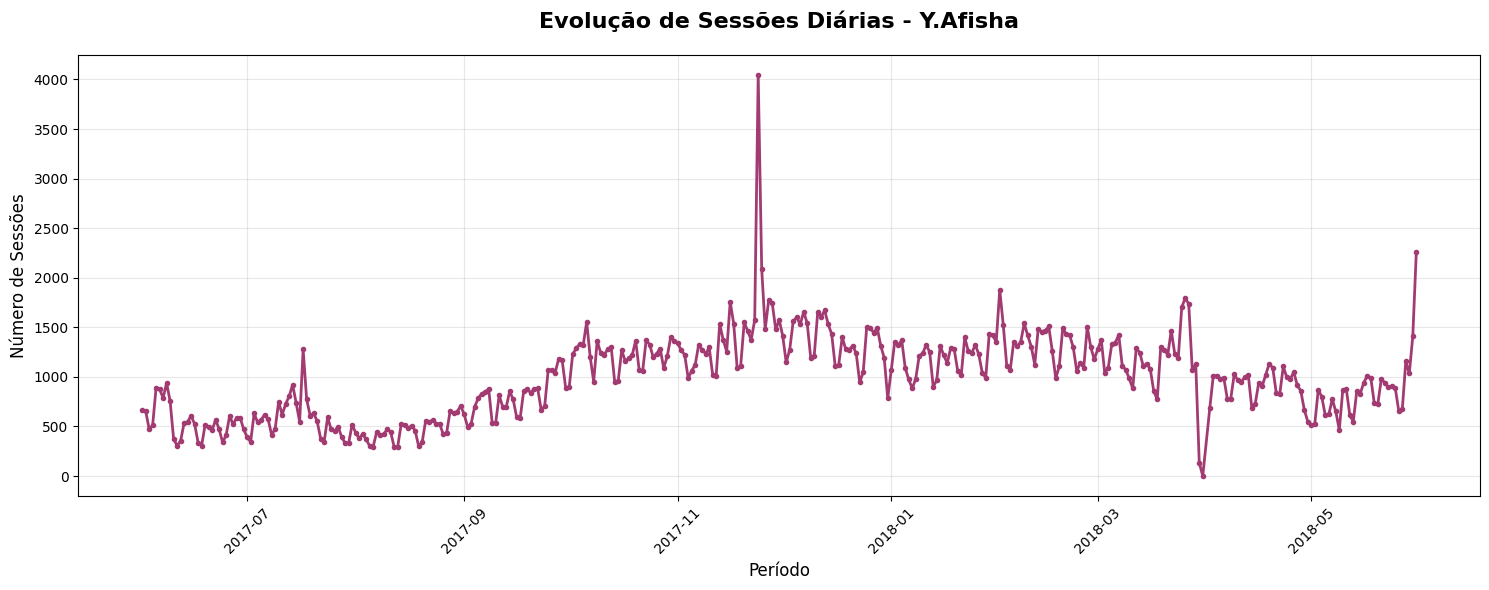

In [16]:
sessions_df = sessions_per_day.reset_index()
sessions_df['date'] = pd.to_datetime(sessions_df['date'])
plt.figure(figsize=(15, 6))
plt.plot(sessions_df['date'], sessions_df[0],
         linewidth=2, color='#A23B72', marker='o', markersize=3)
plt.title('Evolução de Sessões Diárias - Y.Afisha',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Período', fontsize=12)
plt.ylabel('Número de Sessões', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

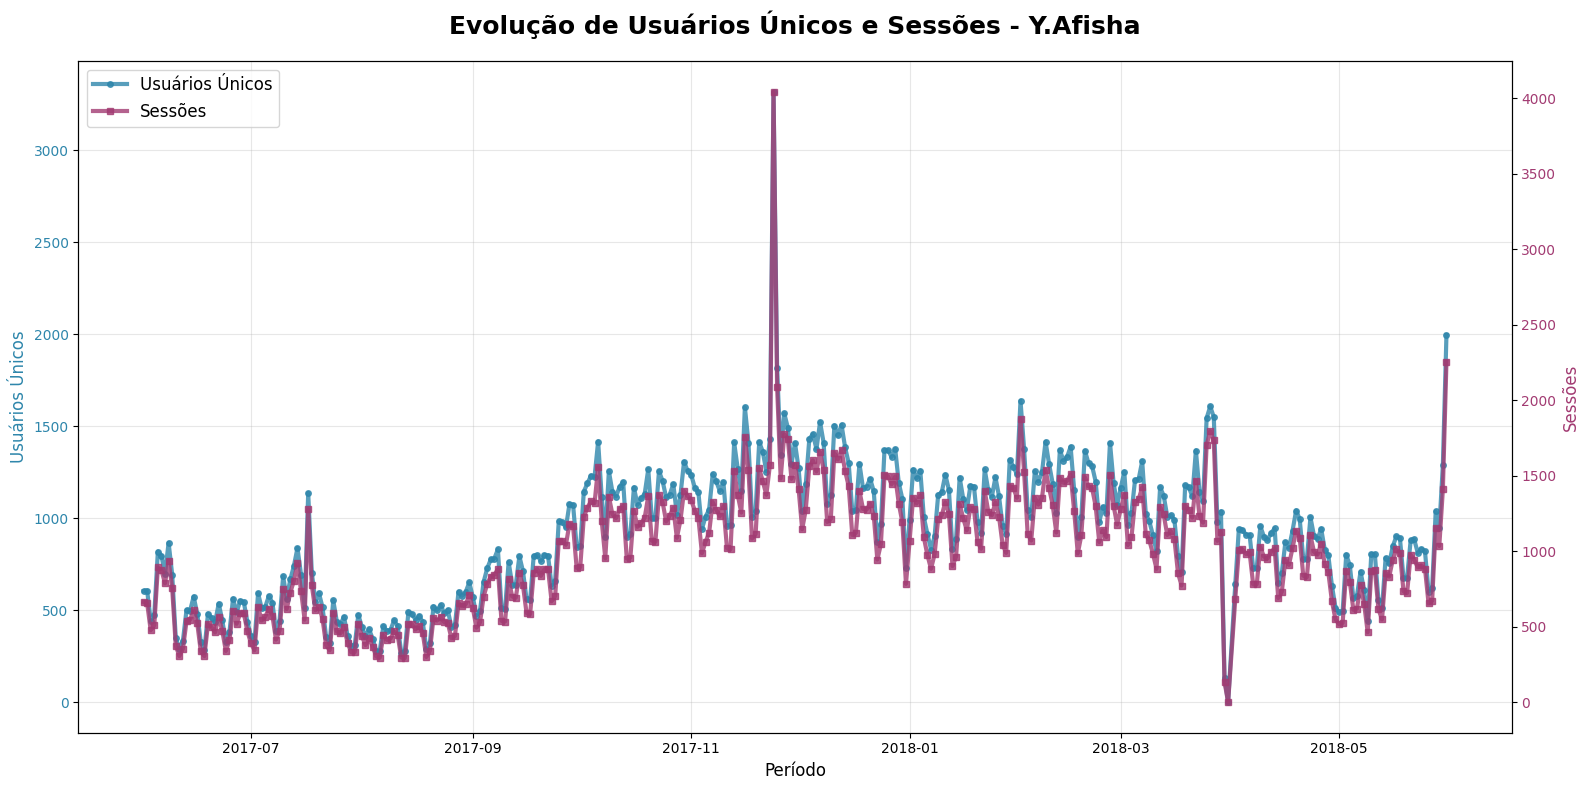

In [17]:
fig, ax1 = plt.subplots(figsize=(16, 8))
color1 = '#2E86AB'
ax1.set_xlabel('Período', fontsize=12)
ax1.set_ylabel('Usuários Únicos', fontsize=12, color=color1)
line1 = ax1.plot(daily_users_df['date'], daily_users_df['Uid'],
                 linewidth=3, color=color1, marker='o', markersize=4,
                 label='Usuários Únicos', alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
color2 = '#A23B72'
ax2.set_ylabel('Sessões', fontsize=12, color=color2)
line2 = ax2.plot(sessions_df['date'], sessions_df[0],
                 linewidth=3, color=color2, marker='s', markersize=4,
                 label='Sessões', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color2)
plt.title('Evolução de Usuários Únicos e Sessões - Y.Afisha',
          fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
conversion_counts = conversion_data['days_to_conversion'].value_counts().sort_index()
total_conversions = len(conversion_data)
conversion_percentages = (conversion_counts / total_conversions * 100).round(2)
print("=== ANÁLISE DE CONVERSÃO ===")
print(f"Total de usuários que converteram: {total_conversions}")
print(f"Taxa de conversão geral: {total_conversions / len(first_visit) * 100:.2f}%")
print("\n=== PORCENTAGENS POR PERÍODO ===")
for days in range(0, min(15, conversion_counts.index.max() + 1)):
    if days in conversion_percentages.index:
        count = conversion_counts[days]
        percentage = conversion_percentages[days]
        print(f"Conversão {days}d: {count:,} usuários ({percentage}%)")

=== ANÁLISE DE CONVERSÃO ===
Total de usuários que converteram: 36523
Taxa de conversão geral: 16.01%

=== PORCENTAGENS POR PERÍODO ===
Conversão 0d: 25,039 usuários (68.56%)
Conversão 1d: 1,966 usuários (5.38%)
Conversão 2d: 685 usuários (1.88%)
Conversão 3d: 452 usuários (1.24%)
Conversão 4d: 386 usuários (1.06%)
Conversão 5d: 307 usuários (0.84%)
Conversão 6d: 264 usuários (0.72%)
Conversão 7d: 237 usuários (0.65%)
Conversão 8d: 216 usuários (0.59%)
Conversão 9d: 162 usuários (0.44%)
Conversão 10d: 135 usuários (0.37%)
Conversão 11d: 121 usuários (0.33%)
Conversão 12d: 91 usuários (0.25%)
Conversão 13d: 126 usuários (0.34%)
Conversão 14d: 123 usuários (0.34%)


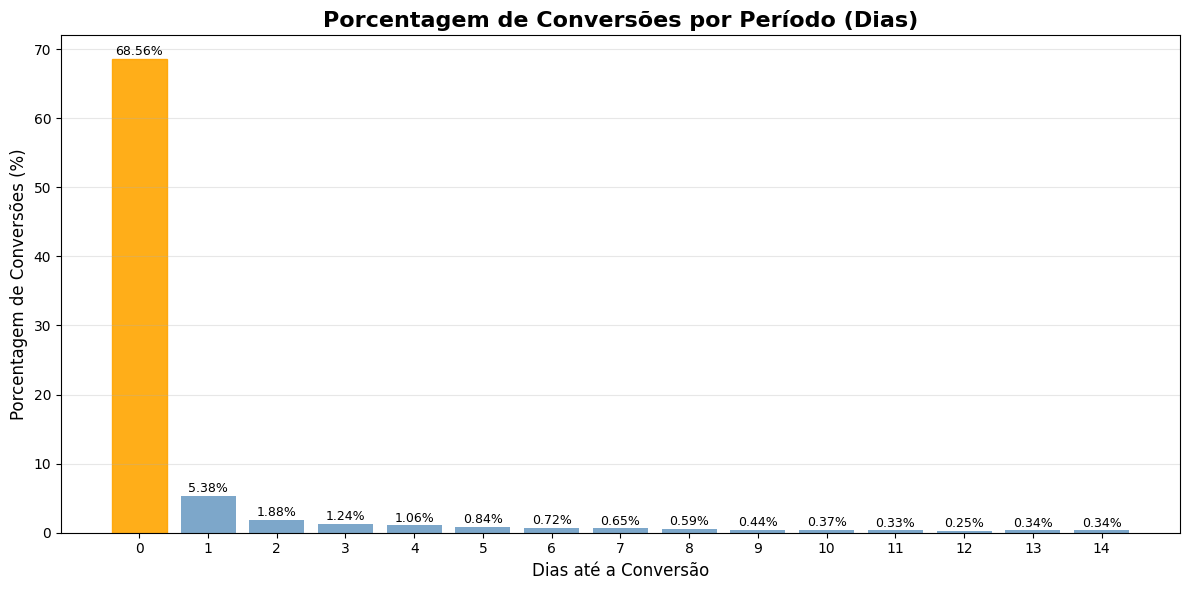

In [19]:
dias = list(range(0, 15))  # Dias 0 a 14
porcentagens = [68.56, 5.38, 1.88, 1.24, 1.06, 0.84, 0.72, 0.65, 0.59, 0.44, 0.37, 0.33, 0.25, 0.34, 0.34]
plt.figure(figsize=(12, 6))
bars = plt.bar(dias, porcentagens, color='steelblue', alpha=0.7)
plt.title('Porcentagem de Conversões por Período (Dias)', fontsize=16, fontweight='bold')
plt.xlabel('Dias até a Conversão', fontsize=12)
plt.ylabel('Porcentagem de Conversões (%)', fontsize=12)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height}%', ha='center', va='bottom', fontsize=9)
bars[0].set_color('orange')
bars[0].set_alpha(0.9)
plt.xticks(dias)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

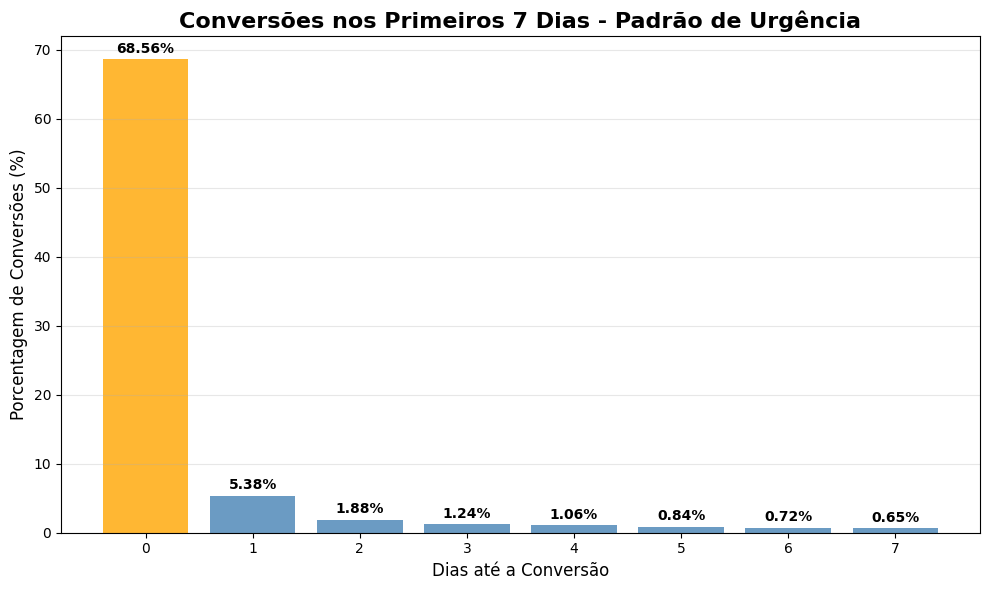

In [20]:
dias_principais = list(range(0, 8))
porcentagens_principais = [68.56, 5.38, 1.88, 1.24, 1.06, 0.84, 0.72, 0.65]
plt.figure(figsize=(10, 6))
bars = plt.bar(dias_principais, porcentagens_principais,
               color=['orange' if i == 0 else 'steelblue' for i in range(len(dias_principais))],
               alpha=0.8)
plt.title('Conversões nos Primeiros 7 Dias - Padrão de Urgência', fontsize=16, fontweight='bold')
plt.xlabel('Dias até a Conversão', fontsize=12)
plt.ylabel('Porcentagem de Conversões (%)', fontsize=12)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(dias_principais)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

This analysis focuses on identifying when customers convert into buyers on the site; I created a chart to make it easier to visualize the results. Out of 228,169 site visitors, approximately 36,523 users made a purchase—about 16% of the total. Regarding the timing of the conversion, around 70% of users completed their purchase on the same day.

In [21]:
pedidos_por_cliente = orders.groupby('Uid').size().reset_index()
pedidos_por_cliente.columns = ['Uid', 'total_pedidos']
print("=== ANÁLISE DE PEDIDOS POR CLIENTE ===")
print(f"Total de clientes únicos: {len(pedidos_por_cliente):,}")
print(f"Total de pedidos: {orders.shape[0]:,}")
print(f"Média de pedidos por cliente: {pedidos_por_cliente['total_pedidos'].mean():.2f}")
print("\n=== DISTRIBUIÇÃO DE PEDIDOS ===")
distribuicao_pedidos = pedidos_por_cliente['total_pedidos'].value_counts().sort_index()
print(distribuicao_pedidos.head(10))

=== ANÁLISE DE PEDIDOS POR CLIENTE ===
Total de clientes únicos: 36,523
Total de pedidos: 50,415
Média de pedidos por cliente: 1.38

=== DISTRIBUIÇÃO DE PEDIDOS ===
total_pedidos
1     30231
2      4395
3      1086
4       375
5       147
6        79
7        41
8        24
9         7
10       15
Name: count, dtype: int64


In [22]:
total_clientes = len(pedidos_por_cliente)
porcentagens_pedidos = (distribuicao_pedidos / total_clientes * 100).round(2)
print("\n=== PORCENTAGENS POR NÚMERO DE PEDIDOS ===")
for pedidos in range(1, min(11, distribuicao_pedidos.index.max() + 1)):
    if pedidos in distribuicao_pedidos.index:
        count = distribuicao_pedidos[pedidos]
        percentage = porcentagens_pedidos[pedidos]
        print(f"{pedidos} pedido(s): {count:,} clientes ({percentage}%)")
clientes_1_pedido = distribuicao_pedidos[1] if 1 in distribuicao_pedidos.index else 0
clientes_multiplos = total_clientes - clientes_1_pedido
print(f"\n=== RESUMO EXECUTIVO ===")
print(f"Clientes com apenas 1 pedido: {clientes_1_pedido:,} ({clientes_1_pedido/total_clientes*100:.1f}%)")
print(f"Clientes com múltiplos pedidos: {clientes_multiplos:,} ({clientes_multiplos/total_clientes*100:.1f}%)")


=== PORCENTAGENS POR NÚMERO DE PEDIDOS ===
1 pedido(s): 30,231 clientes (82.77%)
2 pedido(s): 4,395 clientes (12.03%)
3 pedido(s): 1,086 clientes (2.97%)
4 pedido(s): 375 clientes (1.03%)
5 pedido(s): 147 clientes (0.4%)
6 pedido(s): 79 clientes (0.22%)
7 pedido(s): 41 clientes (0.11%)
8 pedido(s): 24 clientes (0.07%)
9 pedido(s): 7 clientes (0.02%)
10 pedido(s): 15 clientes (0.04%)

=== RESUMO EXECUTIVO ===
Clientes com apenas 1 pedido: 30,231 (82.8%)
Clientes com múltiplos pedidos: 6,292 (17.2%)


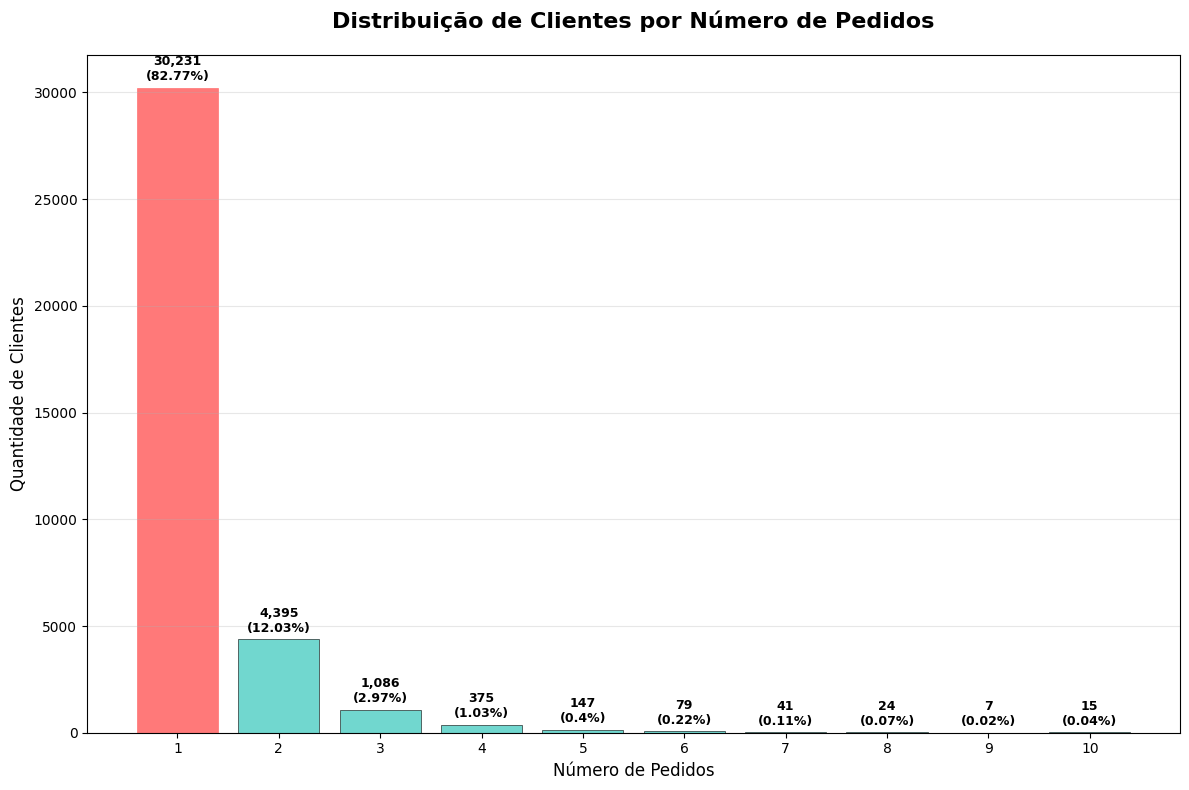

In [23]:
numero_pedidos = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
quantidade_clientes = [30231, 4395, 1086, 375, 147, 79, 41, 24, 7, 15]
porcentagens = [82.77, 12.03, 2.97, 1.03, 0.4, 0.22, 0.11, 0.07, 0.02, 0.04]
plt.figure(figsize=(12, 8))
bars = plt.bar(numero_pedidos, quantidade_clientes,
               color=['#FF6B6B' if i == 0 else '#4ECDC4' for i in range(len(numero_pedidos))],
               alpha=0.8, edgecolor='black', linewidth=0.5)
plt.title('Distribuição de Clientes por Número de Pedidos', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Pedidos', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)
for i, (bar, qtd, pct) in enumerate(zip(bars, quantidade_clientes, porcentagens)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 200,
             f'{qtd:,}\n({pct}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
bars[0].set_color('#FF6B6B')
bars[0].set_alpha(0.9)
plt.xticks(numero_pedidos)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Based on the survey results, we can see that 82% of customers placed only one order, while only 17% placed multiple orders; the chart allows us to see the percentage of orders per customer in greater detail.

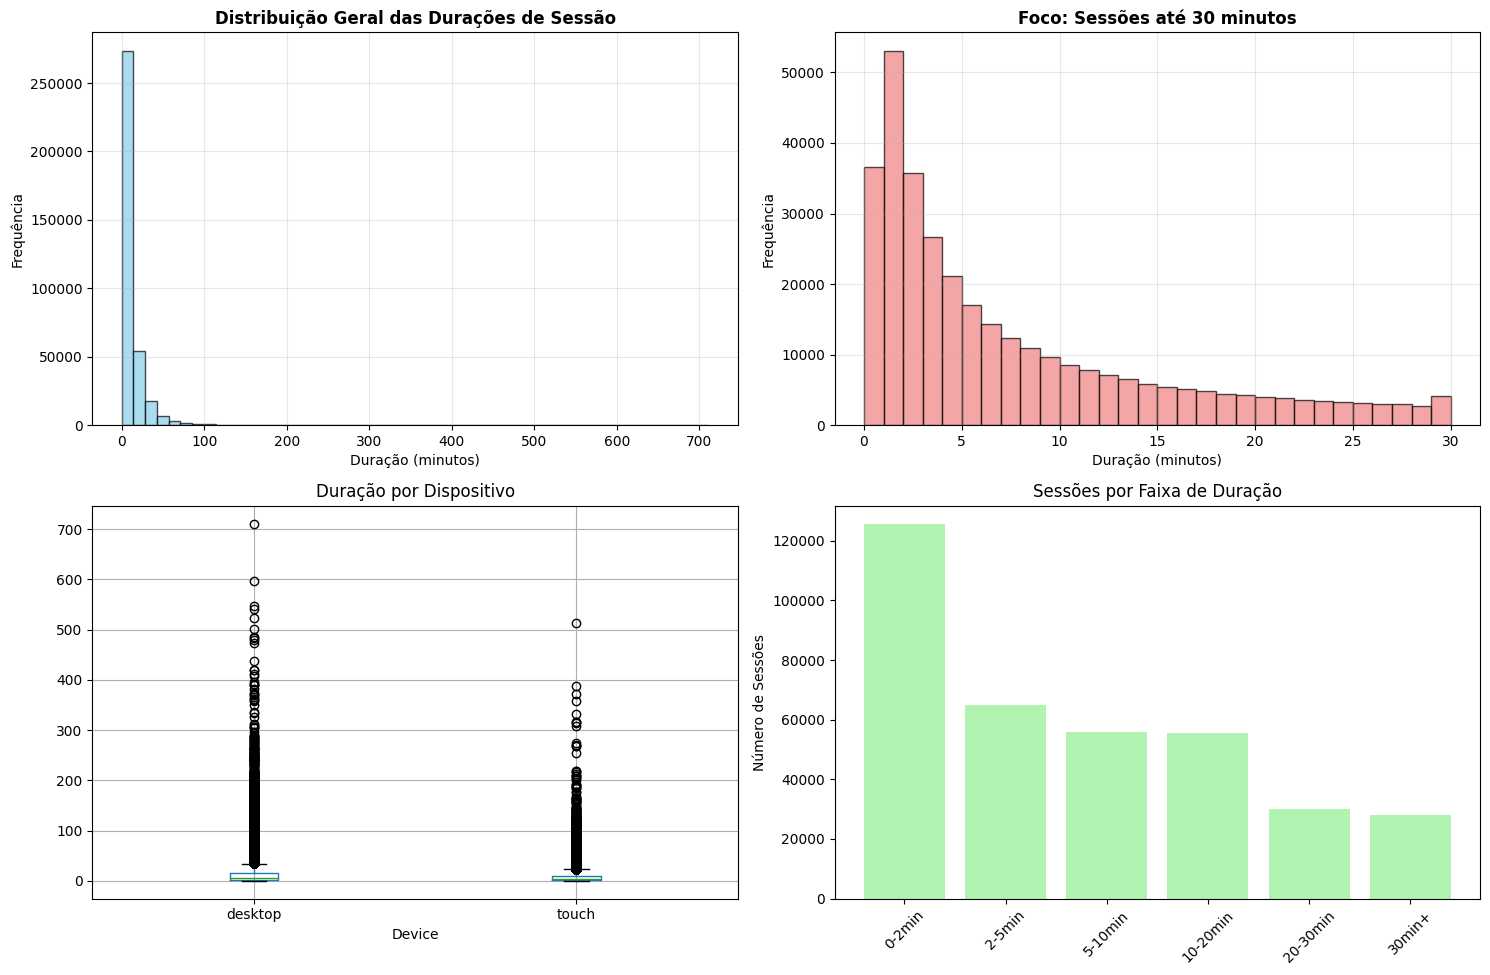

In [24]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.hist(visits_clean['session_duration_min'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribuição Geral das Durações de Sessão', fontweight='bold')
plt.xlabel('Duração (minutos)')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)
plt.subplot(2, 2, 2)
sessoes_curtas = visits_clean[visits_clean['session_duration_min'] <= 30]
plt.hist(sessoes_curtas['session_duration_min'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Foco: Sessões até 30 minutos', fontweight='bold')
plt.xlabel('Duração (minutos)')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)
plt.subplot(2, 2, 3)
visits_clean.boxplot(column='session_duration_min', by='Device', ax=plt.gca())
plt.title('Duração por Dispositivo')
plt.suptitle('')
plt.subplot(2, 2, 4)
faixas = ['0-2min', '2-5min', '5-10min', '10-20min', '20-30min', '30min+']
contagens = [
    len(visits_clean[visits_clean['session_duration_min'] <= 2]),
    len(visits_clean[(visits_clean['session_duration_min'] > 2) & (visits_clean['session_duration_min'] <= 5)]),
    len(visits_clean[(visits_clean['session_duration_min'] > 5) & (visits_clean['session_duration_min'] <= 10)]),
    len(visits_clean[(visits_clean['session_duration_min'] > 10) & (visits_clean['session_duration_min'] <= 20)]),
    len(visits_clean[(visits_clean['session_duration_min'] > 20) & (visits_clean['session_duration_min'] <= 30)]),
    len(visits_clean[visits_clean['session_duration_min'] > 30])
]
plt.bar(faixas, contagens, color='lightgreen', alpha=0.7)
plt.title('Sessões por Faixa de Duração')
plt.xticks(rotation=45)
plt.ylabel('Número de Sessões')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Foco: Sessões até 30 minutos')

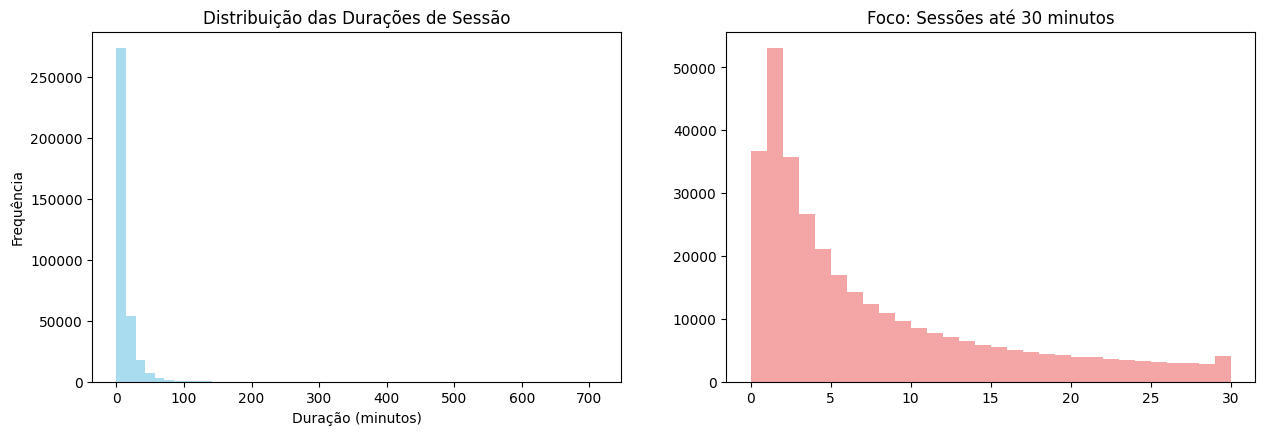

In [25]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.hist(visits_clean['session_duration_min'], bins=50, alpha=0.7, color='skyblue')
plt.title('Distribuição das Durações de Sessão')
plt.xlabel('Duração (minutos)')
plt.ylabel('Frequência')
plt.subplot(2, 2, 2)
sessoes_curtas = visits_clean[visits_clean['session_duration_min'] <= 30]
plt.hist(sessoes_curtas['session_duration_min'], bins=30, alpha=0.7, color='lightcoral')
plt.title('Foco: Sessões até 30 minutos')

In [26]:
print("Valor médio de uma compra é:")
round(orders['Revenue'].mean(), 2)

Valor médio de uma compra é:


np.float64(5.0)

The average purchase volume on Y.Afisha is 5.0 monetary units.

In [27]:
ltv_por_cliente_ordenado = orders.groupby('Uid')['Revenue'].sum().sort_values(ascending=False)
print("LTV por cliente (do maior para o menor):")
print(ltv_por_cliente_ordenado.head(10))

LTV por cliente (do maior para o menor):
Uid
5539673724080479777     11810.18
11149926373378902217    10519.46
17999372575896145244     1979.33
6731421022966725351      1450.68
3644482766749211722      1444.29
9737640335185488211      1310.71
8539015707073391293      1240.76
13888745432979765063     1191.02
1668300487562478408      1163.63
6268225112727843212      1158.32
Name: Revenue, dtype: float64


In [28]:
ltv_medio = ltv_por_cliente_ordenado.mean()
print(f"LTV médio: {ltv_medio:.2f}")

LTV médio: 6.90


This analysis identified the customers who generated the most revenue for the company; the highest-spending customer spent $11,810.18, and a comparison with the overall average reveals a significant difference.

In [29]:
receita_total = orders['Revenue'].sum()
print(f"Receita total: ${receita_total:,.2f}")
orders_with_source = orders.merge(visits[['Uid', 'Source Id']], on='Uid', how='left')
receita_por_fonte = orders_with_source.groupby('Source Id')['Revenue'].sum().sort_values(ascending=False)
print("Receita por fonte de tráfego:")
print(receita_por_fonte)
orders['month'] = orders['Buy Ts'].dt.to_period('M')
receita_mensal = orders.groupby('month')['Revenue'].sum()
print("Receita mensal:")
print(receita_mensal)
orders['buy_date'] = orders['Buy Ts'].dt.date
receita_diaria = orders.groupby('buy_date')['Revenue'].sum()
print("Receita diária (primeiros 10 dias):")
print(receita_diaria.head(10))

Receita total: $252,057.20
Receita por fonte de tráfego:
Source Id
2     2638189.21
1     2298200.17
5     1181477.14
4      496690.17
3      296687.96
9       36342.25
10      14619.23
7           1.22
Name: Revenue, dtype: float64
Receita mensal:
month
2017-06     9557.49
2017-07    12539.47
2017-08     8758.78
2017-09    18345.51
2017-10    27987.70
2017-11    27069.93
2017-12    36388.60
2018-01    19417.13
2018-02    25560.54
2018-03    28834.59
2018-04    16858.06
2018-05    20735.98
2018-06        3.42
Freq: M, Name: Revenue, dtype: float64
Receita diária (primeiros 10 dias):
buy_date
2017-06-01    389.46
2017-06-02    324.11
2017-06-03    166.48
2017-06-04    195.21
2017-06-05    441.49
2017-06-06    543.93
2017-06-07    485.98
2017-06-08    443.85
2017-06-09    566.51
2017-06-10    159.20
Name: Revenue, dtype: float64


We calculated several key metrics and found that total revenue was $252,057.20—a significant figure. Regarding the analysis by traffic source, sources 1 and 2 generate the most revenue, with over $2 million each. The monthly analysis shows interesting revenue growth from June 2017 to December 2017, followed by some fluctuations in 2018.

In [30]:
import numpy as np
import seaborn as sns
primeira_visita = visits_clean.groupby('Uid')['Start Ts'].min().reset_index()
primeira_visita.columns = ['Uid', 'primeira_visita']
primeira_visita['cohort_month'] = primeira_visita['primeira_visita'].dt.to_period('M')
orders_cohort = orders.merge(primeira_visita[['Uid', 'cohort_month']], on='Uid', how='left')
orders_cohort['order_month'] = orders_cohort['Buy Ts'].dt.to_period('M')
orders_cohort['periodo'] = (orders_cohort['order_month'] - orders_cohort['cohort_month']).apply(lambda x: x.n)
print("Dados preparados para análise de cohort:")
print(orders_cohort[['Uid', 'cohort_month', 'order_month', 'periodo', 'Revenue']].head())

Dados preparados para análise de cohort:
                    Uid cohort_month order_month  periodo  Revenue
0  10329302124590727494      2017-06     2017-06        0    17.00
1  11627257723692907447      2017-06     2017-06        0     0.55
2  17903680561304213844      2017-06     2017-06        0     0.37
3  16109239769442553005      2017-06     2017-06        0     0.55
4  14200605875248379450      2017-06     2017-06        0     0.37


In [31]:
ltv_cohort = orders_cohort.groupby(['cohort_month', 'periodo'])['Revenue'].sum().reset_index()
ltv_table = ltv_cohort.pivot(index='cohort_month', columns='periodo', values='Revenue').fillna(0)
ltv_cumulative = ltv_table.cumsum(axis=1)
print("Tabela de LTV Acumulado por Cohort:")
print(ltv_cumulative.round(2))

Tabela de LTV Acumulado por Cohort:
periodo             0         1         2         3         4         5   \
cohort_month                                                               
2017-06        9557.49  12222.07  13686.76  17568.85  21509.44  24333.92   
2017-07        9874.89  10934.17  12043.07  13026.03  13873.02  14671.10   
2017-08        6234.81   7232.13   8233.48   9179.69   9989.73  10522.63   
2017-09       12357.20  16057.68  18168.31  28607.24  29895.72  31805.77   
2017-10       18362.32  22172.15  23499.17  24557.22  25600.69  26622.88   
2017-11       16531.79  19199.37  20542.22  21911.75  23020.49  23728.12   
2017-12       16857.00  18596.03  22794.33  27918.15  29375.72  31157.85   
2018-01       10597.01  12548.71  13713.47  14019.35  14546.82  14546.82   
2018-02       11512.63  13497.09  14160.28  15061.29  15061.29  15061.29   
2018-03       12011.39  12995.39  13770.16  13770.16  13770.16  13770.16   
2018-04        8043.82   9882.55   9882.55   9882.55

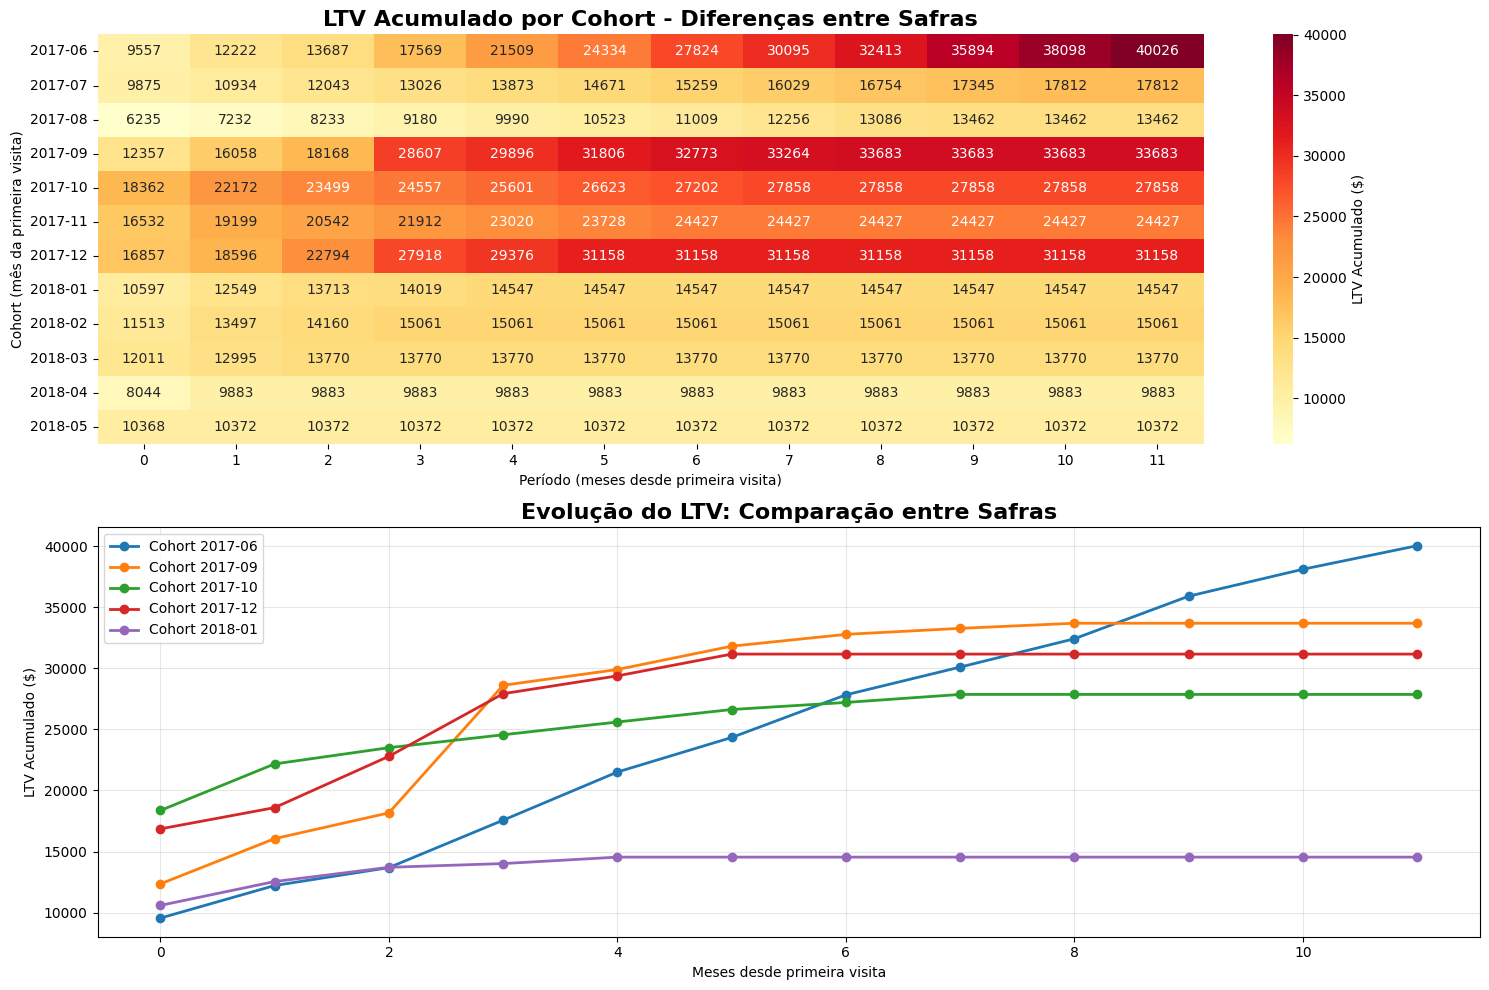

In [32]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
sns.heatmap(ltv_cumulative.iloc[:12, :12],
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            cbar_kws={'label': 'LTV Acumulado ($)'})
plt.title('LTV Acumulado por Cohort - Diferenças entre Safras', fontsize=16, fontweight='bold')
plt.xlabel('Período (meses desde primeira visita)')
plt.ylabel('Cohort (mês da primeira visita)')
plt.subplot(2, 1, 2)
cohorts_principais = ['2017-06', '2017-09', '2017-10', '2017-12', '2018-01']
for cohort in cohorts_principais:
    if cohort in ltv_cumulative.index:
        plt.plot(range(12), ltv_cumulative.loc[cohort, :11],
                marker='o', linewidth=2, label=f'Cohort {cohort}')
plt.title('Evolução do LTV: Comparação entre Safras', fontsize=16, fontweight='bold')
plt.xlabel('Meses desde primeira visita')
plt.ylabel('LTV Acumulado ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
print("=== ANÁLISE DE COHORT: DIFERENÇAS ENTRE SAFRAS ===")
ltv_final = ltv_cumulative.iloc[:, -1].sort_values(ascending=False)
print("LTV Final por Cohort (após 12 meses):")
for cohort, valor in ltv_final.head(6).items():
    print(f"Cohort {cohort}: ${valor:,.2f}")

=== ANÁLISE DE COHORT: DIFERENÇAS ENTRE SAFRAS ===
LTV Final por Cohort (após 12 meses):
Cohort 2017-06: $40,026.05
Cohort 2017-09: $33,682.56
Cohort 2017-12: $31,157.85
Cohort 2017-10: $27,857.69
Cohort 2017-11: $24,426.72
Cohort 2017-07: $17,812.11


In [34]:
usuarios_por_coorte = primeira_visita.groupby('cohort_month')['Uid'].nunique()
ltv_medio_por_usuario = ltv_cumulative.div(usuarios_por_coorte, axis=0)
print("=== LTV MÉDIO POR USUÁRIO ===")
print(ltv_medio_por_usuario.round(2))

=== LTV MÉDIO POR USUÁRIO ===
periodo         0     1     2     3     4     5     6     7     8     9   \
cohort_month                                                               
2017-06       0.72  0.92  1.03  1.33  1.62  1.84  2.10  2.27  2.44  2.71   
2017-07       0.75  0.83  0.92  0.99  1.06  1.12  1.16  1.22  1.28  1.32   
2017-08       0.61  0.71  0.81  0.90  0.98  1.03  1.08  1.20  1.29  1.32   
2017-09       0.74  0.96  1.09  1.71  1.79  1.90  1.96  1.99  2.02  2.02   
2017-10       0.71  0.85  0.90  0.95  0.99  1.02  1.05  1.07  1.07  1.07   
2017-11       0.61  0.70  0.75  0.80  0.84  0.87  0.90  0.90  0.90  0.90   
2017-12       0.67  0.74  0.90  1.10  1.16  1.23  1.23  1.23  1.23  1.23   
2018-01       0.47  0.55  0.61  0.62  0.64  0.64  0.64  0.64  0.64  0.64   
2018-02       0.52  0.61  0.64  0.68  0.68  0.68  0.68  0.68  0.68  0.68   
2018-03       0.58  0.63  0.67  0.67  0.67  0.67  0.67  0.67  0.67  0.67   
2018-04       0.51  0.63  0.63  0.63  0.63  0.63  0.63  0.

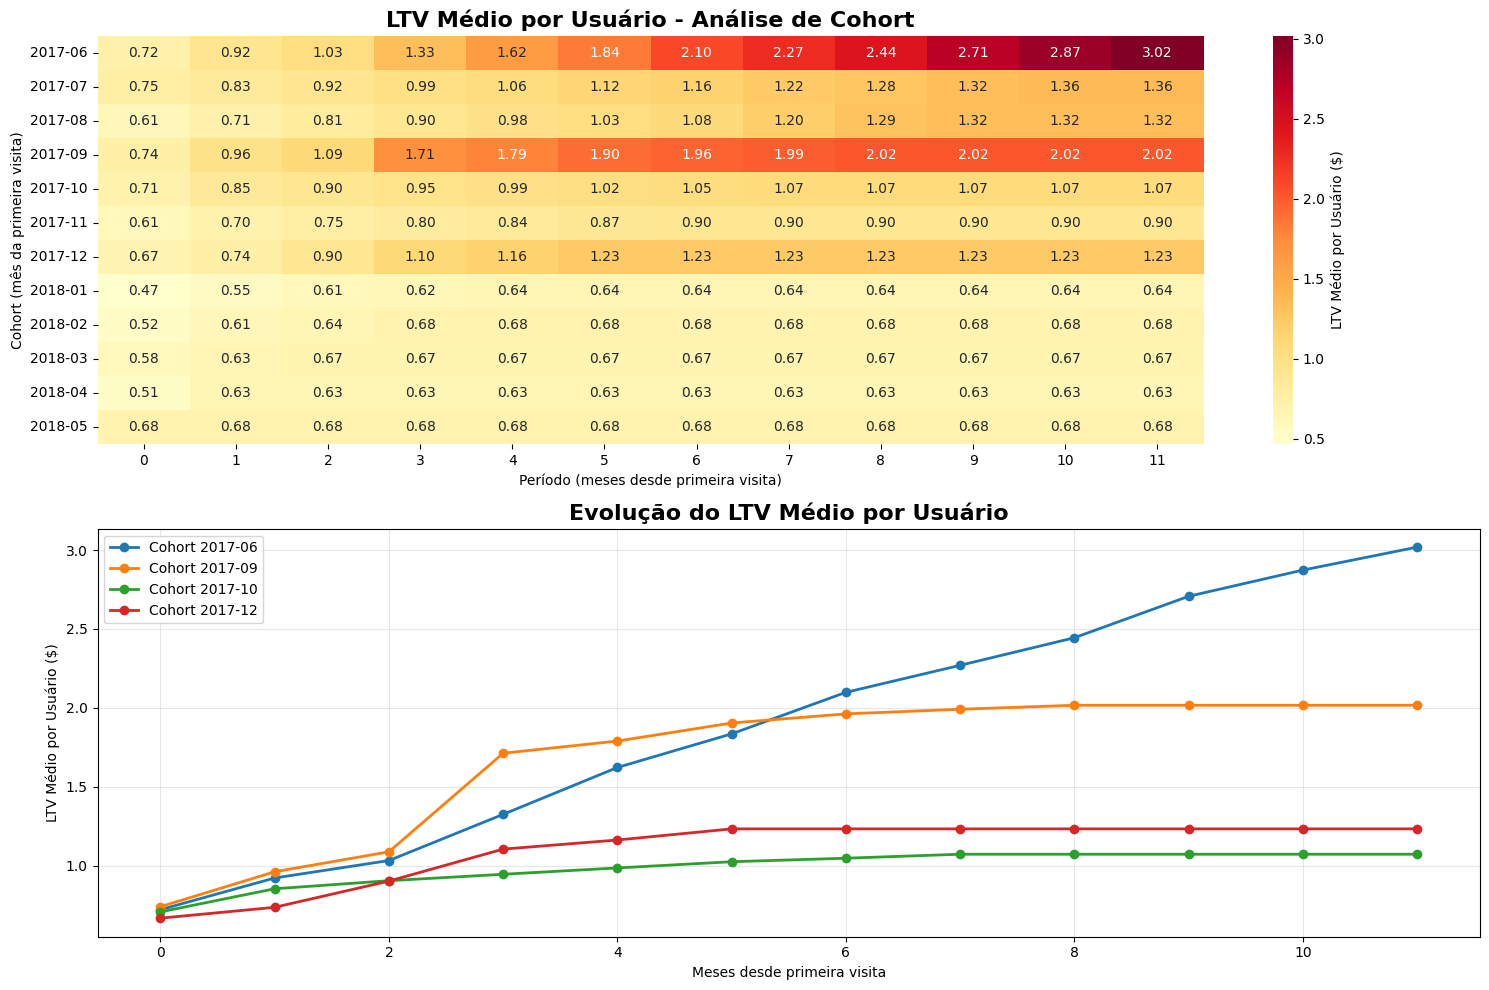

In [35]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
sns.heatmap(ltv_medio_por_usuario.iloc[:12, :12],
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            cbar_kws={'label': 'LTV Médio por Usuário ($)'})
plt.title('LTV Médio por Usuário - Análise de Cohort', fontsize=16, fontweight='bold')
plt.xlabel('Período (meses desde primeira visita)')
plt.ylabel('Cohort (mês da primeira visita)')
plt.subplot(2, 1, 2)
cohorts_principais = ['2017-06', '2017-09', '2017-10', '2017-12']
for cohort in cohorts_principais:
    if cohort in ltv_medio_por_usuario.index:
        plt.plot(range(12), ltv_medio_por_usuario.loc[cohort, :11],
                marker='o', linewidth=2, label=f'Cohort {cohort}')

plt.title('Evolução do LTV Médio por Usuário', fontsize=16, fontweight='bold')
plt.xlabel('Meses desde primeira visita')
plt.ylabel('LTV Médio por Usuário ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
custos_por_fonte = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print("Custos totais por fonte:")
print(custos_por_fonte)

Custos totais por fonte:
source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64


Here, we can see the marketing spend for each traffic source during 2017 and 2018; Source 3 was the most expensive, accounting for the largest advertising budget, while Source 4 represented the second-highest investment cost. Regarding the sources that generated the most revenue, Source 1 produced 2.3 million in revenue at a cost of 20,833.27, and Source 2 generated 2.6 million in revenue at a cost of 42,806.04.

In [37]:
primeira_visita_por_usuario = visits_clean.groupby('Uid').agg({
    'Start Ts': 'min',
    'Source Id': 'first'
}).reset_index()
orders_corrigido = orders.merge(
    primeira_visita_por_usuario[['Uid', 'Source Id']],
    on='Uid',
    how='left'
)
receita_corrigida = orders_corrigido.groupby('Source Id')['Revenue'].sum().sort_values(ascending=False)
print("Receita por fonte:")
print(receita_corrigida)
for fonte in receita_corrigida.index:
    if fonte in custos_por_fonte.index:
        receita = receita_corrigida[fonte]
        custo = custos_por_fonte[fonte]
        roi = (receita - custo) / custo * 100
        print(f"Fonte {fonte}: ROI = {roi:.2f}%")

Receita por fonte:
Source Id
2     65152.26
4     52479.75
3     44317.68
5     40357.91
1     38560.06
9      7076.98
10     4111.34
7         1.22
Name: Revenue, dtype: float64
Fonte 2: ROI = 52.20%
Fonte 4: ROI = -14.07%
Fonte 3: ROI = -68.64%
Fonte 5: ROI = -22.02%
Fonte 1: ROI = 85.09%
Fonte 9: ROI = 28.26%
Fonte 10: ROI = -29.39%


Volume de clientes únicos por fonte:
Source Id
4     9823
3     9138
5     6839
2     4323
1     3743
9     1415
10    1241
7        1
Name: Uid, dtype: int64


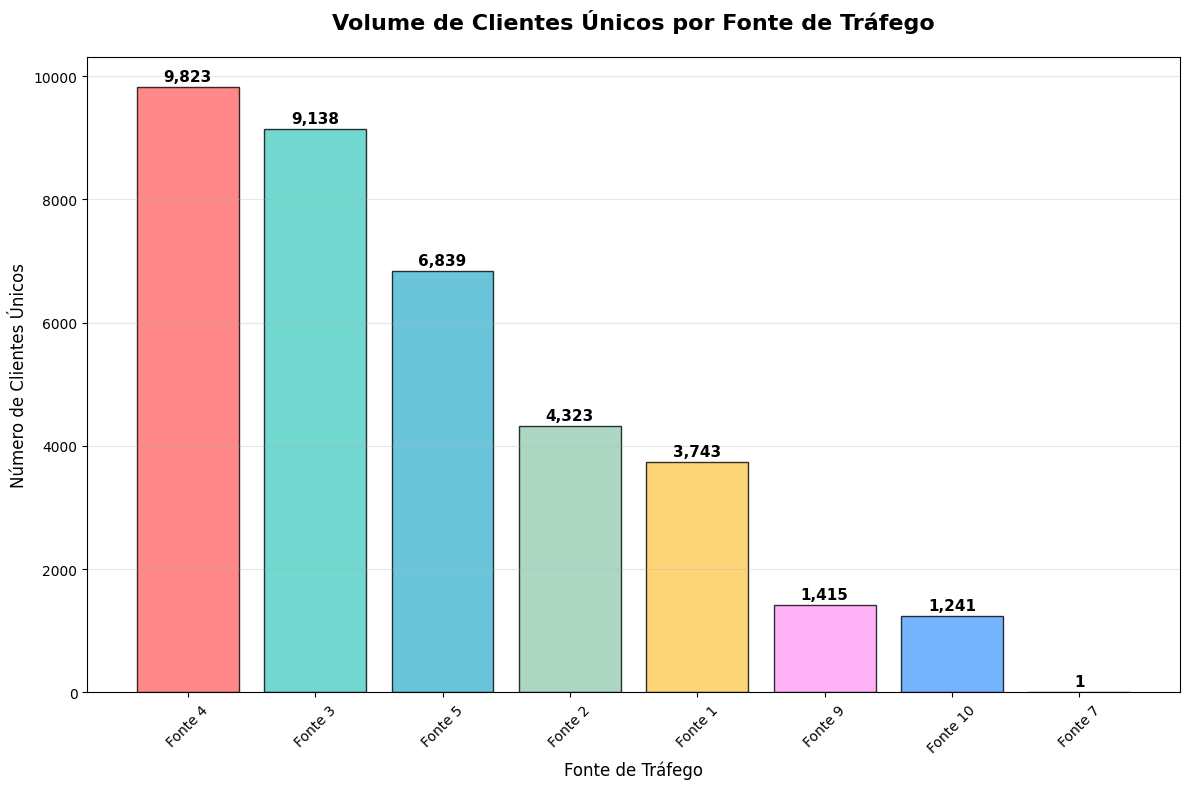


=== ESTATÍSTICAS DE CLIENTES ÚNICOS ===
Total de clientes únicos: 36,523
Fonte com mais clientes: Fonte 4 (9,823 clientes)
Fonte com menos clientes: Fonte 7 (1 clientes)


In [38]:
clientes_unicos_por_fonte = orders_corrigido.groupby('Source Id')['Uid'].nunique().sort_values(ascending=False)
print("Volume de clientes únicos por fonte:")
print(clientes_unicos_por_fonte)
plt.figure(figsize=(12, 8))
fontes = [f'Fonte {int(fonte)}' for fonte in clientes_unicos_por_fonte.index]
volumes = clientes_unicos_por_fonte.values
cores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3', '#54A0FF']
bars = plt.bar(fontes, volumes, color=cores[:len(fontes)], alpha=0.8, edgecolor='black', linewidth=1)
plt.title('Volume de Clientes Únicos por Fonte de Tráfego', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fonte de Tráfego', fontsize=12)
plt.ylabel('Número de Clientes Únicos', fontsize=12)
for i, (bar, volume) in enumerate(zip(bars, volumes)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{volume:,}',
             ha='center', va='bottom',
             fontweight='bold', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\n=== ESTATÍSTICAS DE CLIENTES ÚNICOS ===")
print(f"Total de clientes únicos: {clientes_unicos_por_fonte.sum():,}")
print(f"Fonte com mais clientes: Fonte {clientes_unicos_por_fonte.index[0]} ({clientes_unicos_por_fonte.iloc[0]:,} clientes)")
print(f"Fonte com menos clientes: Fonte {clientes_unicos_por_fonte.index[-1]} ({clientes_unicos_por_fonte.iloc[-1]:,} clientes)")

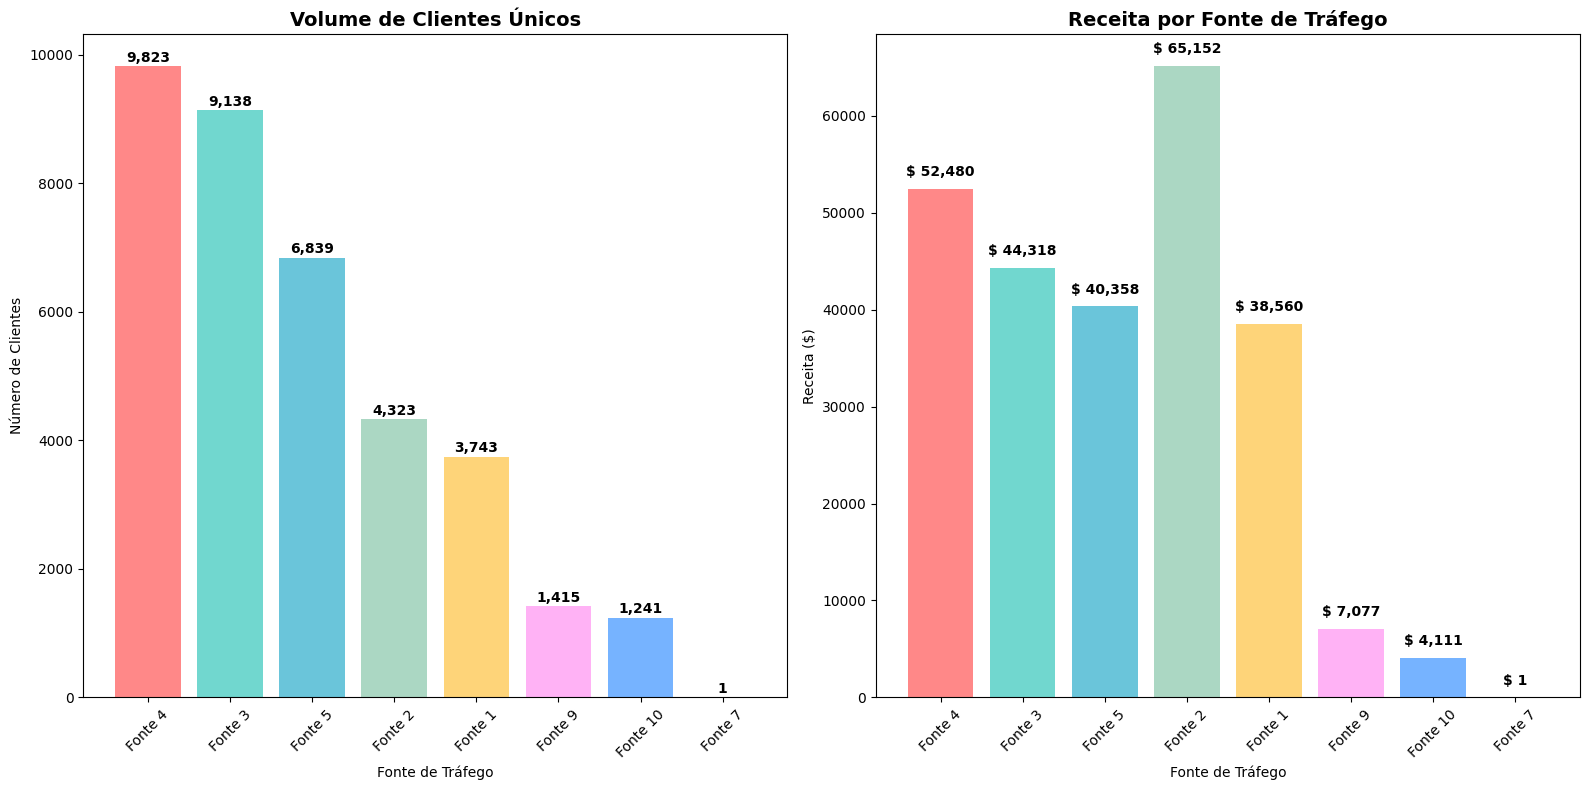

=== ANÁLISE COMPARATIVA ===
Fonte 4: 9,823 clientes | $ 52,479.75 | $ 5.34 por cliente
Fonte 3: 9,138 clientes | $ 44,317.68 | $ 4.85 por cliente
Fonte 5: 6,839 clientes | $ 40,357.91 | $ 5.90 por cliente
Fonte 2: 4,323 clientes | $ 65,152.26 | $ 15.07 por cliente
Fonte 1: 3,743 clientes | $ 38,560.06 | $ 10.30 por cliente
Fonte 9: 1,415 clientes | $ 7,076.98 | $ 5.00 por cliente
Fonte 10: 1,241 clientes | $ 4,111.34 | $ 3.31 por cliente
Fonte 7: 1 clientes | $ 1.22 | $ 1.22 por cliente


In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
clientes_unicos_por_fonte = orders_corrigido.groupby('Source Id')['Uid'].nunique().sort_values(ascending=False)
receita_por_fonte = orders_corrigido.groupby('Source Id')['Revenue'].sum().sort_values(ascending=False)
fontes = [f'Fonte {int(fonte)}' for fonte in clientes_unicos_por_fonte.index]
volumes = clientes_unicos_por_fonte.values
receitas = [receita_por_fonte.get(fonte_id, 0) for fonte_id in clientes_unicos_por_fonte.index]
cores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3', '#54A0FF']
bars1 = ax1.bar(fontes, volumes, color=cores[:len(fontes)], alpha=0.8)
ax1.set_title('Volume de Clientes Únicos', fontsize=14, fontweight='bold')
ax1.set_xlabel('Fonte de Tráfego')
ax1.set_ylabel('Número de Clientes')
ax1.tick_params(axis='x', rotation=45)
for i, (bar, volume) in enumerate(zip(bars1, volumes)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{volume:,}',
             ha='center', va='bottom',
             fontweight='bold', fontsize=10)
bars2 = ax2.bar(fontes, receitas, color=cores[:len(fontes)], alpha=0.8)
ax2.set_title('Receita por Fonte de Tráfego', fontsize=14, fontweight='bold')
ax2.set_xlabel('Fonte de Tráfego')
ax2.set_ylabel('Receita ($)')
ax2.tick_params(axis='x', rotation=45)
for i, (bar, receita) in enumerate(zip(bars2, receitas)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'$ {receita:,.0f}',
             ha='center', va='bottom',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()
print("=== ANÁLISE COMPARATIVA ===")
for i, fonte in enumerate(fontes):
    fonte_id = clientes_unicos_por_fonte.index[i]
    volume = volumes[i]
    receita = receitas[i]
    receita_por_cliente = receita / volume if volume > 0 else 0
    print(f"{fonte}: {volume:,} clientes | $ {receita:,.2f} | $ {receita_por_cliente:.2f} por cliente")

Receita por dispositivo:
Device
desktop    6447893.99
touch       514313.36
Name: Revenue, dtype: float64


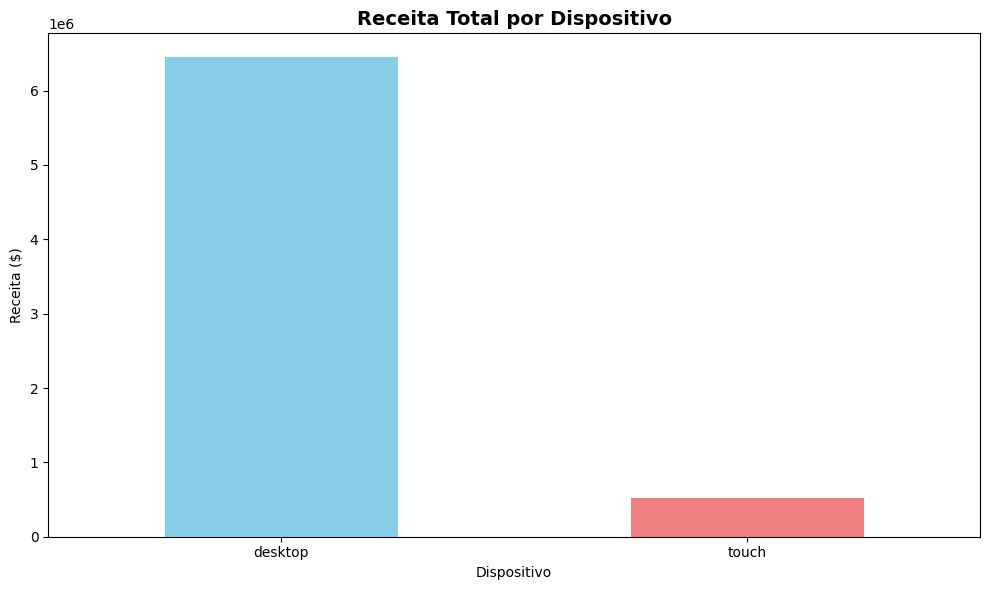

In [40]:
orders_with_device = orders.merge(visits[['Uid', 'Device']], on='Uid', how='left')
receita_por_device = orders_with_device.groupby('Device')['Revenue'].sum()
print("Receita por dispositivo:")
print(receita_por_device)
plt.figure(figsize=(10, 6))
receita_por_device.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Receita Total por Dispositivo', fontsize=14, fontweight='bold')
plt.xlabel('Dispositivo')
plt.ylabel('Receita ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

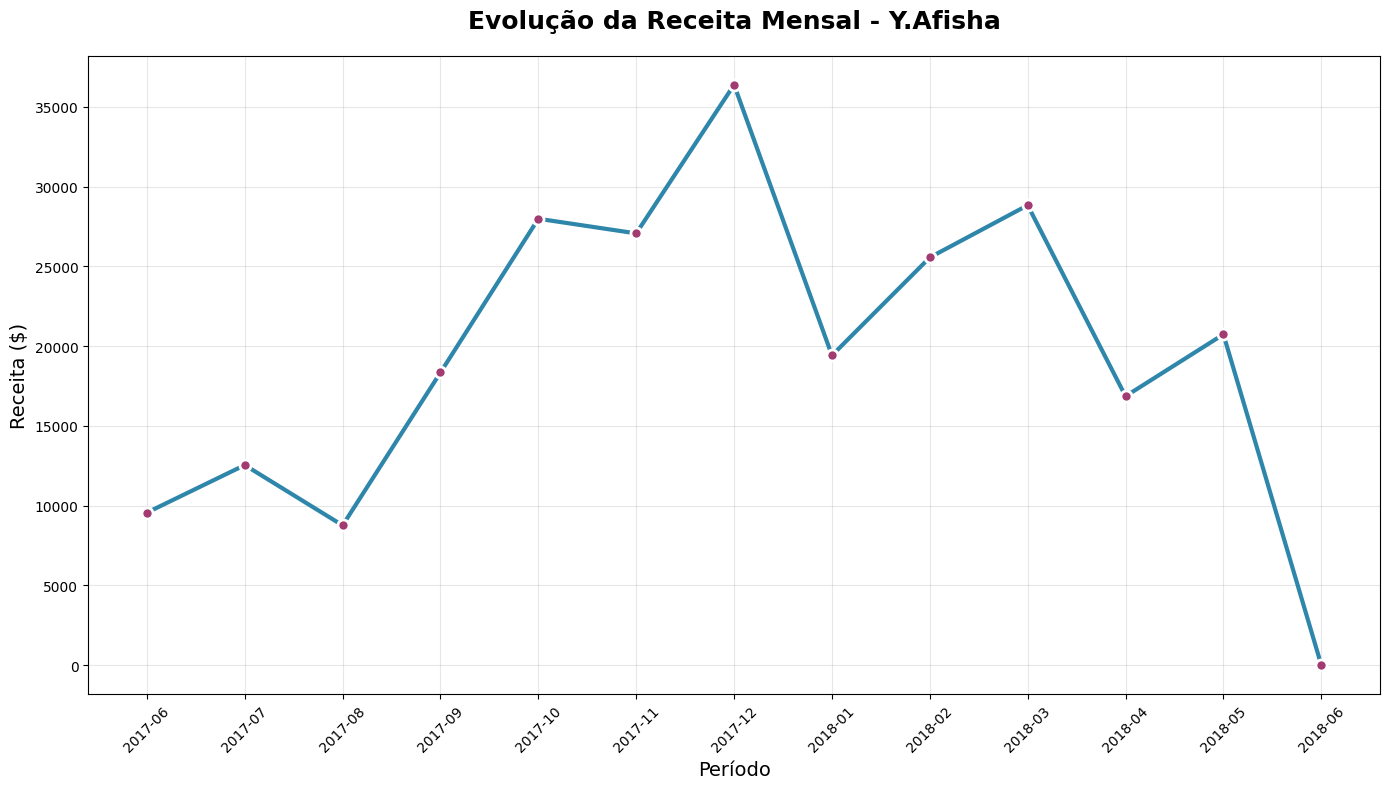

In [41]:
meses = ['2017-06', '2017-07', '2017-08', '2017-09', '2017-10',
         '2017-11', '2017-12', '2018-01', '2018-02', '2018-03',
         '2018-04', '2018-05', '2018-06']
receitas = [9557.49, 12539.47, 8758.78, 18345.51, 27987.70,
           27069.93, 36388.60, 19417.13, 25560.54, 28834.59,
           16858.06, 20735.98, 3.42]
plt.figure(figsize=(14, 8))
plt.plot(meses, receitas, marker='o', linewidth=3, markersize=8,
         color='#2E86AB', markerfacecolor='#A23B72', markeredgecolor='white', markeredgewidth=2)
plt.title('Evolução da Receita Mensal - Y.Afisha', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Período', fontsize=14)
plt.ylabel('Receita ($)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

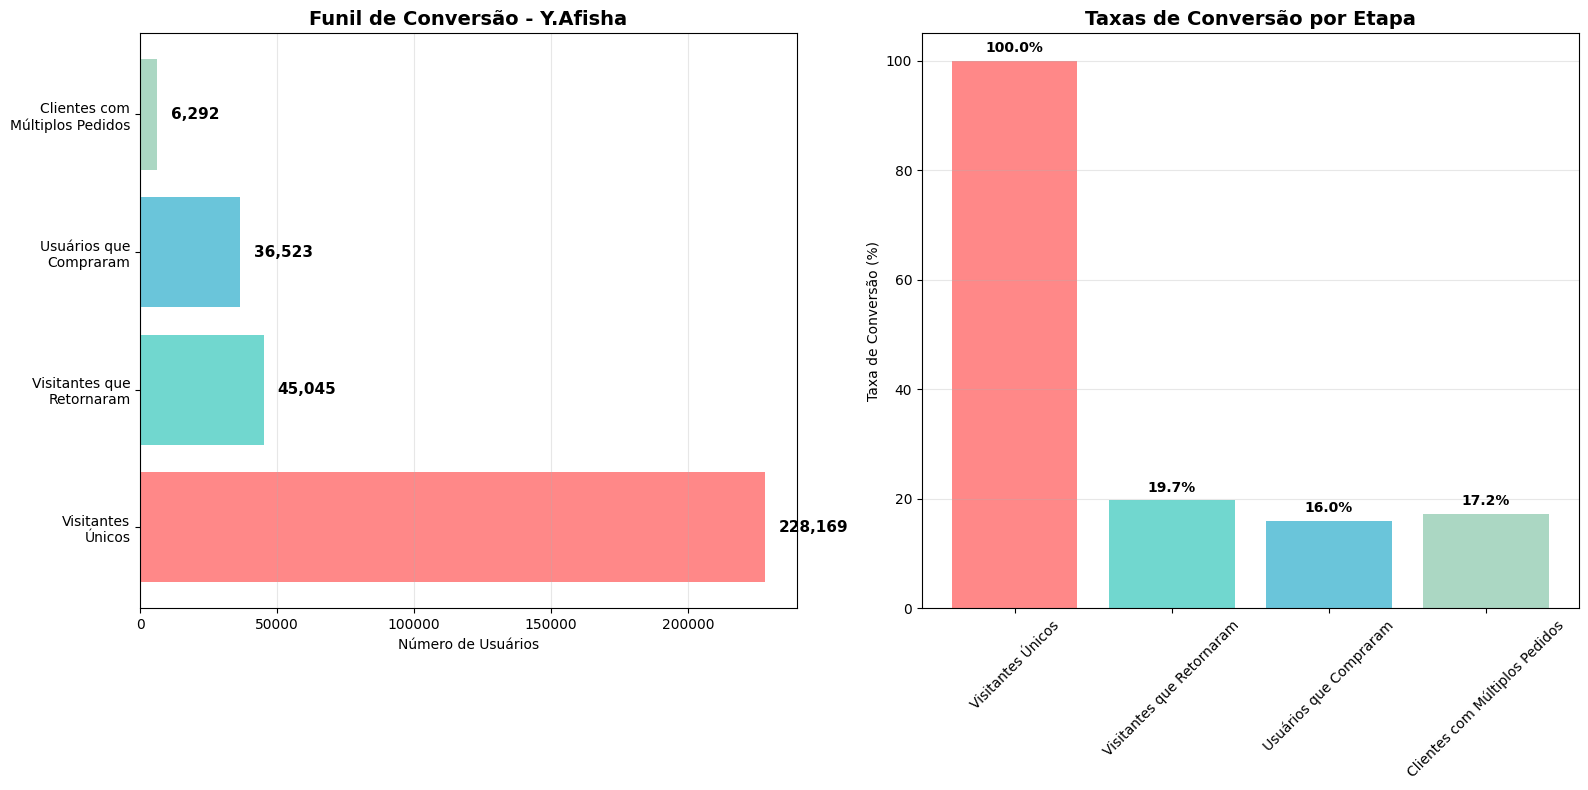

=== INSIGHTS DO FUNIL DE CONVERSÃO ===
📊 Total de visitantes únicos: 228,169
🔄 Taxa de retorno: 19.7%
💰 Taxa de conversão: 16.0%
🎯 Taxa de fidelização: 17.2%

=== ANÁLISE DETALHADA ===
• De cada 100 visitantes únicos:
  - 20 retornam ao site
  - 16 fazem pelo menos uma compra
  - 17% dos compradores fazem múltiplos pedidos

=== OPORTUNIDADES DE MELHORIA ===
🚀 PRIORIDADE ALTA:
• Aumentar taxa de retorno (atual: 19.7%)
• Implementar estratégias de retenção

💡 PRIORIDADE MÉDIA:
• Melhorar conversão de visitantes recorrentes
• Aumentar fidelização de clientes (atual: 17.2%)


In [42]:
etapas = ['Visitantes\nÚnicos', 'Visitantes que\nRetornaram', 'Usuários que\nCompraram', 'Clientes com\nMúltiplos Pedidos']
valores = [228169, 45045, 36523, 6292]
cores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
taxa_retorno = (45045 / 228169) * 100
taxa_conversao = (36523 / 228169) * 100
taxa_fidelizacao = (6292 / 36523) * 100
plt.figure(figsize=(12, 10))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
y_pos = np.arange(len(etapas))
bars = ax1.barh(y_pos, valores, color=cores, alpha=0.8)
for i, (bar, valor) in enumerate(zip(bars, valores)):
    width = bar.get_width()
    ax1.text(width + 5000, bar.get_y() + bar.get_height()/2,
             f'{valor:,}', ha='left', va='center', fontweight='bold', fontsize=11)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(etapas)
ax1.set_xlabel('Número de Usuários')
ax1.set_title('Funil de Conversão - Y.Afisha', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
taxas = [100, taxa_retorno, taxa_conversao, taxa_fidelizacao]
bars2 = ax2.bar(range(len(etapas)), taxas, color=cores, alpha=0.8)
for i, (bar, taxa) in enumerate(zip(bars2, taxas)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{taxa:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.set_xticks(range(len(etapas)))
ax2.set_xticklabels([etapa.replace('\n', ' ') for etapa in etapas], rotation=45)
ax2.set_ylabel('Taxa de Conversão (%)')
ax2.set_title('Taxas de Conversão por Etapa', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("=== INSIGHTS DO FUNIL DE CONVERSÃO ===")
print(f"📊 Total de visitantes únicos: {valores[0]:,}")
print(f"🔄 Taxa de retorno: {taxa_retorno:.1f}%")
print(f"💰 Taxa de conversão: {taxa_conversao:.1f}%")
print(f"🎯 Taxa de fidelização: {taxa_fidelizacao:.1f}%")
print()
print("=== ANÁLISE DETALHADA ===")
print(f"• De cada 100 visitantes únicos:")
print(f"  - {taxa_retorno:.0f} retornam ao site")
print(f"  - {taxa_conversao:.0f} fazem pelo menos uma compra")
print(f"  - {taxa_fidelizacao:.0f}% dos compradores fazem múltiplos pedidos")
print()
print("=== OPORTUNIDADES DE MELHORIA ===")
print("🚀 PRIORIDADE ALTA:")
print(f"• Aumentar taxa de retorno (atual: {taxa_retorno:.1f}%)")
print("• Implementar estratégias de retenção")
print()
print("💡 PRIORIDADE MÉDIA:")
print(f"• Melhorar conversão de visitantes recorrentes")
print(f"• Aumentar fidelização de clientes (atual: {taxa_fidelizacao:.1f}%)")

The analysis of Y.Afisha's data reveals a highly positive scenario, while also highlighting clear opportunities for strategic improvement. The results show that the business already benefits from highly profitable traffic sources and has a proven ability to generate revenue. However, current growth is mainly constrained by the way the marketing budget is allocated and by the low level of customer retention over time.

From an investment perspective, **Source 1** stands out as the primary growth driver. Its exceptionally high ROI demonstrates that every dollar invested generates returns well above average, justifying a significant increase in budget allocation, provided that performance is continuously monitored to ensure sustained efficiency. **Sources 2 and 5** play an important complementary strategic role, as they generate higher revenue volumes and offer greater scalability, despite having a lower ROI than Source 1. For these channels, the priority should be campaign optimization, focusing on cost reduction, more precise audience targeting, and improved conversion rates. **Source 4**, on the other hand, should be treated as a testing and learning environment, receiving controlled investments to validate hypotheses before any more aggressive expansion.

Beyond media allocation, the conversion funnel data reveal important challenges. The visitor return rate, currently at **19.7%**, is well below the industry benchmark, indicating that a large proportion of users do not return to the website after their first visit. This underscores the need to invest in customer retention strategies such as remarketing, email marketing, push notifications, and personalized offers. Likewise, the customer loyalty rate of only **17.2%** indicates that relatively few customers make repeat purchases, limiting the company's long-term sustainable growth. Implementing loyalty programs, repeat-purchase coupons, and structured post-sales initiatives is therefore essential to increase customer lifetime value.

By implementing these recommendations, a significant positive impact on the company's key performance indicators is expected. Concentrating investments on the most efficient traffic sources should drive substantial revenue growth, while retention and loyalty initiatives are expected to increase customer repeat rates, reduce customer acquisition costs, and improve the overall average ROI. Over the medium term, this combination of actions will create a stronger, more predictable, and more scalable foundation for Y.Afisha's growth.

In summary, the data indicate that the company's next stage of growth depends not only on attracting more visitors but, more importantly, on optimizing marketing investments, retaining users, and converting one-time buyers into loyal, repeat customers. This approach will enable more sustainable growth, greater operational efficiency, and stronger financial performance in the long run.
